## Block 0   — Setup

In [1]:
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data' / 'scania'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'

(MODELS_DIR / 'pkl').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'onnx').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'data').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)

COST_FP = 10
COST_FN = 500

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Cost weights: FP={COST_FP}, FN={COST_FN}, ratio={COST_FN // COST_FP}")

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('Set2')

Project root: d:\v2
Data dir:     d:\v2\data\scania
Cost weights: FP=10, FN=500, ratio=50


## Block 1   — Load Data 

In [2]:
t0 = time.time()
train = pd.read_csv(DATA_DIR / 'aps_failure_training_set.csv', na_values='na')
test  = pd.read_csv(DATA_DIR / 'aps_failure_test_set.csv', na_values='na')
print(f"Loaded in {time.time()-t0:.1f} sec")

print(f"\nTrain: {train.shape}")
print(f"Test:  {test.shape}")
print(f"\nClass distribution:")
print(f"  Train: {train['class'].value_counts().to_dict()}")
print(f"  Test:  {test['class'].value_counts().to_dict()}")
print(f"\nFirst 3 rows:")
print(train.head(3))

Loaded in 1.2 sec

Train: (60000, 171)
Test:  (16000, 171)

Class distribution:
  Train: {'neg': 59000, 'pos': 1000}
  Test:  {'neg': 15625, 'pos': 375}

First 3 rows:
  class  aa_000  ab_000        ac_000  ad_000  ae_000  af_000  ag_000  ag_001  \
0   neg   76698     NaN  2.130706e+09   280.0     0.0     0.0     0.0     0.0   
1   neg   33058     NaN  0.000000e+00     NaN     0.0     0.0     0.0     0.0   
2   neg   41040     NaN  2.280000e+02   100.0     0.0     0.0     0.0     0.0   

   ag_002  ...     ee_002    ee_003    ee_004    ee_005    ee_006    ee_007  \
0     0.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0  157956.0   
1     0.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   81140.0   
2     0.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0  158022.0   

    ee_008  ee_009  ef_000  eg_000  
0  73224.0     0.0     0.0     0.0  
1  97576.0  1500.0     0.0     0.0  
2  95128.0   514.0     0.0     0.0  

[3 rows x 171 columns]


## Block 2   — EDA: missing values and class imbalance

Missing value statistics (train):
  Features with >50% NaN: 8
  Features with >80% NaN: 2
  Mean NaN %:             8.3%
  Max NaN % per feature:  82.1%

Class imbalance (train):
  Negative: 59,000  (98.3%)
  Positive: 1,000  (1.7%)
  Ratio:    59.0:1


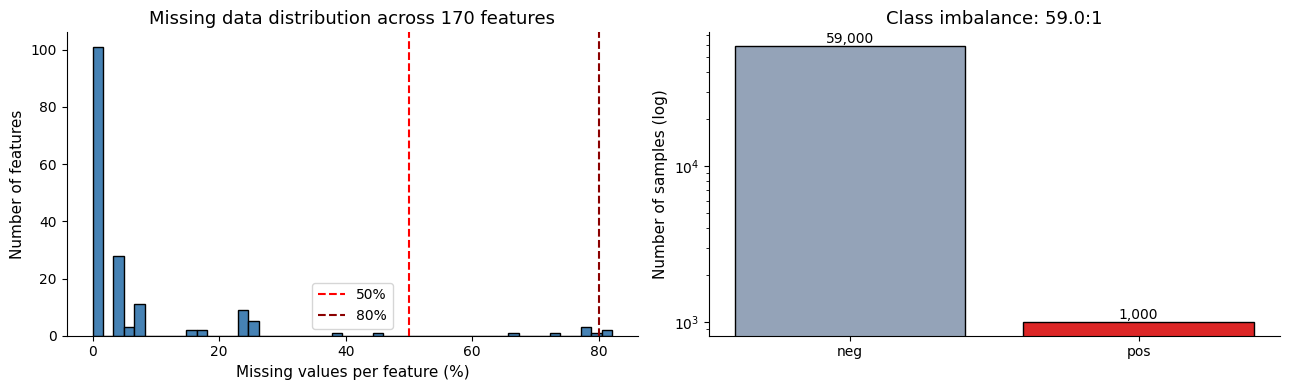

In [3]:
nan_pct = train.isna().mean() * 100
print(f"Missing value statistics (train):")
print(f"  Features with >50% NaN: {(nan_pct > 50).sum()}")
print(f"  Features with >80% NaN: {(nan_pct > 80).sum()}")
print(f"  Mean NaN %:             {nan_pct.mean():.1f}%")
print(f"  Max NaN % per feature:  {nan_pct.max():.1f}%")

n_neg = (train['class'] == 'neg').sum()
n_pos = (train['class'] == 'pos').sum()
print(f"\nClass imbalance (train):")
print(f"  Negative: {n_neg:,}  ({n_neg/len(train)*100:.1f}%)")
print(f"  Positive: {n_pos:,}  ({n_pos/len(train)*100:.1f}%)")
print(f"  Ratio:    {n_neg/n_pos:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(nan_pct, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(50, color='red', linestyle='--', label='50%')
axes[0].axvline(80, color='darkred', linestyle='--', label='80%')
axes[0].set_xlabel('Missing values per feature (%)')
axes[0].set_ylabel('Number of features')
axes[0].set_title('Missing data distribution across 170 features')
axes[0].legend()

axes[1].bar(['neg', 'pos'], [n_neg, n_pos], color=['#94a3b8', '#dc2626'], edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_ylabel('Number of samples (log)')
axes[1].set_title(f'Class imbalance: {n_neg/n_pos:.1f}:1')
for i, v in enumerate([n_neg, n_pos]):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'aps_01_eda.png', bbox_inches='tight')
plt.show()

## Block 3   — Feature engineering

In [4]:
y_train = (train['class'] == 'pos').astype(int).values
y_test  = (test['class']  == 'pos').astype(int).values

X_train = train.drop(columns=['class']).values
X_test  = test.drop(columns=['class']).values

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

feature_names = [c for c in train.columns if c != 'class']

print(f"Final shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}  (positives: {y_train.sum():,})")
print(f"  y_test:  {y_test.shape}  (positives: {y_test.sum():,})")
print(f"  Features: {len(feature_names)}")

Final shapes:
  X_train: (60000, 170)
  X_test:  (16000, 170)
  y_train: (60000,)  (positives: 1,000)
  y_test:  (16000,)  (positives: 375)
  Features: 170


## Block 4   — Train XGBoost

In [5]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

xgb_params = {
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': -1,
    'eval_metric': 'aucpr',
}

t0 = time.time()
model = xgb.XGBClassifier(**xgb_params)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=100)
train_time = time.time() - t0

proba_test = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)

print(f"\nTrained in {train_time:.1f} sec")
print(f"ROC AUC: {auc:.4f}")
print(f"\nProba distribution on test:")
print(f"  Min:    {proba_test.min():.6f}")
print(f"  Median: {np.median(proba_test):.6f}")
print(f"  Mean:   {proba_test.mean():.6f}")
print(f"  Max:    {proba_test.max():.6f}")

[0]	validation_0-aucpr:0.68881
[100]	validation_0-aucpr:0.91746
[200]	validation_0-aucpr:0.92926
[300]	validation_0-aucpr:0.93301
[400]	validation_0-aucpr:0.93286
[499]	validation_0-aucpr:0.93273

Trained in 8.2 sec
ROC AUC: 0.9958

Proba distribution on test:
  Min:    0.000001
  Median: 0.000072
  Mean:   0.020058
  Max:    0.999602


## Block 5   — Threshold sweep

In [ ]:
from sklearn.metrics import precision_recall_curve, auc as sk_auc
import plotly.graph_objects as go

thresholds = np.logspace(-4, 0, 100)
costs = []
fps = []
fns = []

for thr in thresholds:
    pred = (proba_test >= thr).astype(int)
    fp = int(((y_test == 0) & (pred == 1)).sum())
    fn = int(((y_test == 1) & (pred == 0)).sum())
    cost = COST_FP * fp + COST_FN * fn
    costs.append(cost)
    fps.append(fp)
    fns.append(fn)

costs = np.array(costs)
fps = np.array(fps)
fns = np.array(fns)

best_idx = costs.argmin()
optimal_threshold = thresholds[best_idx]
optimal_cost = int(costs[best_idx])
optimal_fp = int(fps[best_idx])
optimal_fn = int(fns[best_idx])

default_pred = (proba_test >= 0.5).astype(int)
default_fp = int(((y_test == 0) & (default_pred == 1)).sum())
default_fn = int(((y_test == 1) & (default_pred == 0)).sum())
default_cost = COST_FP * default_fp + COST_FN * default_fn

precision_arr, recall_arr, _ = precision_recall_curve(y_test, proba_test)
pr_auc = sk_auc(recall_arr, precision_arr)
optimal_pred = (proba_test >= optimal_threshold).astype(int)
optimal_precision = float(((y_test == 1) & (optimal_pred == 1)).sum()) / max(optimal_pred.sum(), 1)
optimal_recall    = float(((y_test == 1) & (optimal_pred == 1)).sum()) / max((y_test == 1).sum(), 1)

improvement_pct = (default_cost - optimal_cost) / default_cost * 100
print(f"Threshold sweep:")
print(f"  Default τ=0.5:        Cost = {default_cost:>6,}  (FP = {default_fp}, FN = {default_fn})")
print(f"  Optimal τ={optimal_threshold:.4f}:  Cost = {optimal_cost:>6,}  (FP = {optimal_fp}, FN = {optimal_fn})")
print(f"  Improvement:          {improvement_pct:.1f}%")


fig = go.Figure()

custom = np.column_stack([fps, fns])

fig.add_trace(go.Scatter(
    x=thresholds,
    y=costs,
    mode='lines',
    name='Total Cost',
    line=dict(color='#3B82F6', width=2.5),
    customdata=custom,
    hovertemplate=(
        'τ = <b>%{x:.4f}</b><br>'
        'Total Cost = <b>%{y:,.0f}</b><br>'
        'FP = %{customdata[0]}<br>'
        'FN = %{customdata[1]}<extra></extra>'
    ),
))

fig.add_trace(go.Scatter(
    x=[0.5], y=[default_cost],
    mode='markers',
    name=f'Default τ=0.5 → {default_cost:,}',
    marker=dict(color='#DC2626', size=15, symbol='circle', line=dict(color='white', width=2)),
    hovertemplate=(
        f'<b>Default threshold τ = 0.5</b><br>'
        f'Total Cost = {default_cost:,}<br>'
        f'FP = {default_fp}<br>FN = {default_fn}<extra></extra>'
    ),
))

fig.add_trace(go.Scatter(
    x=[optimal_threshold], y=[optimal_cost],
    mode='markers',
    name=f'Optimal τ={optimal_threshold:.3f} → {optimal_cost:,}',
    marker=dict(color='#10B981', size=17, symbol='star', line=dict(color='white', width=2)),
    hovertemplate=(
        f'<b>Optimal threshold τ = {optimal_threshold:.4f}</b><br>'
        f'Total Cost = {optimal_cost:,}<br>'
        f'FP = {optimal_fp}<br>FN = {optimal_fn}<extra></extra>'
    ),
))

fig.add_annotation(
    x=np.log10(optimal_threshold), y=optimal_cost,
    text=f'<b>−{improvement_pct:.1f}%</b><br>cost reduction',
    showarrow=True, arrowhead=2, arrowcolor='#10B981', arrowwidth=2,
    ax=80, ay=-55,
    bgcolor='rgba(16,185,129,0.12)', bordercolor='#10B981', borderwidth=1, borderpad=6,
    font=dict(family='Plus Jakarta Sans', size=11, color='#065F46'),
)

fig.update_layout(
    title=dict(
        text='Threshold sweep · Total Cost as a function of decision threshold τ',
        font=dict(family='Plus Jakarta Sans, sans-serif', size=15, color='#0F172A'),
        x=0.02, xanchor='left',
    ),
    xaxis=dict(
        title=dict(text='Decision threshold τ (log scale)',
                   font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='JetBrains Mono', size=11, color='#64748B'),
        gridcolor='#E2E8F0', type='log', showline=False, zeroline=False,
    ),
    yaxis=dict(
        title=dict(text='Total Cost = 10·FP + 500·FN',
                   font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='JetBrains Mono', size=11, color='#64748B'),
        gridcolor='#E2E8F0', showline=False, zeroline=False,
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=80, r=40, t=70, b=80),
    height=420,
    legend=dict(orientation='h', yanchor='top', y=-0.2, xanchor='left', x=0,
                font=dict(family='Plus Jakarta Sans', size=11)),
    font=dict(family='Plus Jakarta Sans, sans-serif'),
    hoverlabel=dict(bgcolor='#0F172A', bordercolor='#0F172A',
                    font=dict(family='Plus Jakarta Sans', size=12, color='white')),
)

plot_json_path = OUTPUTS_DIR / 'data' / 'aps_02_threshold_sweep_plot.json'
plot_json_path.write_text(fig.to_json(), encoding='utf-8')
print(f"\nPlotly JSON: {plot_json_path.name}  ({plot_json_path.stat().st_size / 1024:.1f} KB)")

png_path = OUTPUTS_DIR / 'plots' / 'aps_02_threshold_sweep.png'
try:
    fig.write_image(png_path, width=950, height=450, scale=2)
    print(f"PNG:         {png_path.name}  ({png_path.stat().st_size / 1024:.1f} KB)")
except Exception as e:
    print(f"PNG export skipped — pip install -U kaleido  ({type(e).__name__})")

fig.show()


Threshold sweep:
  Default τ=0.5:        Cost = 44,140  (FP = 14, FN = 88)
  Optimal τ=0.0060:  Cost =  8,910  (FP = 491, FN = 8)
  Improvement:          79.8%

Plotly JSON: aps_02_threshold_sweep_plot.json  (11.5 KB)
PNG:         aps_02_threshold_sweep.png  (126.6 KB)


## Block 6   — Cost-sensitive predictions

In [7]:
optimal_pred = (proba_test >= optimal_threshold).astype(int)

fp = int(((y_test == 0) & (optimal_pred == 1)).sum())
fn = int(((y_test == 1) & (optimal_pred == 0)).sum())
tp = int(((y_test == 1) & (optimal_pred == 1)).sum())
tn = int(((y_test == 0) & (optimal_pred == 0)).sum())

total_cost = COST_FP * fp + COST_FN * fn
precision = tp / max(tp + fp, 1)
recall    = tp / max(tp + fn, 1)
f1        = 2 * precision * recall / max(precision + recall, 1e-9)

print(f"Predictions at optimal threshold τ={optimal_threshold:.6f}:")
print(f"  TP: {tp:>5,}")
print(f"  FP: {fp:>5,}")
print(f"  TN: {tn:>5,}")
print(f"  FN: {fn:>5,}")
print(f"\nMetrics:")
print(f"  Total Cost: {total_cost:,}  ({COST_FP}*{fp} + {COST_FN}*{fn})")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  F1 score:   {f1:.4f}")

Predictions at optimal threshold τ=0.005995:
  TP:   367
  FP:   491
  TN: 15,134
  FN:     8

Metrics:
  Total Cost: 8,910  (10*491 + 500*8)
  Precision:  0.4277
  Recall:     0.9787
  F1 score:   0.5953


## Block 7   — Evaluation visualization

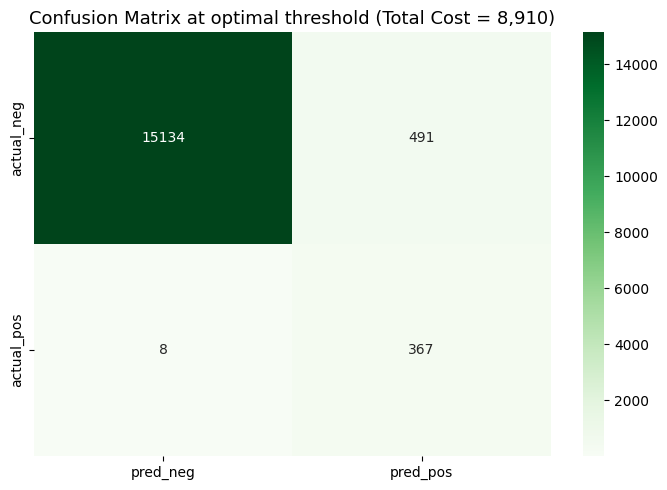

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, optimal_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['pred_neg', 'pred_pos'],
            yticklabels=['actual_neg', 'actual_pos'])
ax.set_title(f'Confusion Matrix at optimal threshold (Total Cost = {total_cost:,})')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'aps_03_confusion_matrix.png', bbox_inches='tight')
plt.show()

## Block 8   — Comparison vs published baselines

In [ ]:
import plotly.graph_objects as go

published_baselines = [
    {'study': 'Taghandiki 2023',         'method': 'DNN',                          'fp':  77, 'fn': 137,   'cost': 69270, 'year': 2023, 'note': 'mean imputation, no class balancing'},
    {'study': 'Oh 2020',                 'method': 'GPR + DNN',                    'fp': 207, 'fn':  59,   'cost': 31570, 'year': 2020, 'note': 'GAN oversampling'},
    {'study': 'Syed 2020',               'method': 'Linear Classifier',            'fp': 519, 'fn':  30,   'cost': 20190, 'year': 2020, 'note': 'KNN imputation, AUC max'},
    {'study': 'Ke 2022',                 'method': 'LSTM',                         'fp': 229, 'fn':  28,   'cost': 16290, 'year': 2022, 'note': 'sequential learning'},
    {'study': 'Rafsunjani 2019',         'method': 'Random Forest',                'fp': 771, 'fn':   9,   'cost': 12210, 'year': 2019, 'note': 'best of imputation comparison'},
    {'study': 'Akarte 2018',             'method': 'XGBoost',                      'fp': 414, 'fn':  12,   'cost': 10140, 'year': 2018, 'note': 'median imputation, class weights'},
    {'study': 'Costa & Nascimento 2017', 'method': 'IDA 2016 winner',              'fp': None,'fn': None,  'cost':  9920, 'year': 2017, 'note': 'Industrial Challenge winner'},
    {'study': 'Sun 2023',                'method': 'Siamese NN',                   'fp': 608, 'fn':   6,   'cost':  9080, 'year': 2023, 'note': 'contrastive learning, multi-shot voting'},
    {'study': 'Ranasinghe 2019 (RF)',    'method': 'Random Forest + CGAN',         'fp': 405, 'fn':   4,   'cost':  6050, 'year': 2019, 'note': 'conditional GAN oversampling'},
    {'study': 'Ranasinghe 2019 (GBM)',   'method': 'Gradient Boosting + CGAN',     'fp': 255, 'fn':   6,   'cost':  5550, 'year': 2019, 'note': 'conditional GAN oversampling'},
    {'study': 'Oh 2023',                 'method': 'Quantum DNN',                  'fp':   0, 'fn':   8,   'cost':  4000, 'year': 2023, 'note': 'quantum mech-based missing value est.'},
    {'study': 'Beikmohammadi 2024',      'method': 'Cost-Sensitive Transformer',   'fp':   4, 'fn':   7,   'cost':  3440, 'year': 2024, 'note': 'SVM-SMOTE + Repeated ENN + Focal Loss', 'sota': True},
]

our_result = {
    'study': 'OUR WORK (XGBoost + threshold)',
    'method': 'XGBoost binary + cost-sensitive threshold',
    'fp': int(optimal_fp),
    'fn': int(optimal_fn),
    'cost': int(optimal_cost),
    'year': 2026,
    'note': 'no resampling, only threshold tuning',
}

# Sort ASCENDING by cost (lowest cost = best, sits at top of bar chart)
all_results = sorted(published_baselines + [our_result], key=lambda x: x['cost'])

print(f"{'Rank':<5} {'Study':<32} {'Method':<32} {'FP':>6} {'FN':>6} {'Cost':>8}")
print("-" * 95)
for i, r in enumerate(all_results, 1):
    is_us   = 'OUR WORK' in r['study']
    is_sota = r.get('sota', False)
    marker = ' ★' if is_sota else (' ←' if is_us else '')
    fp_str = f"{r['fp']:>6}" if r['fp'] is not None else f"{'—':>6}"
    fn_str = f"{r['fn']:>6}" if r['fn'] is not None else f"{'—':>6}"
    print(f"  {i:<3} {r['study']:<32} {r['method']:<32} {fp_str} {fn_str} {r['cost']:>7,}{marker}")

our_rank = next(i for i, r in enumerate(all_results, 1) if 'OUR WORK' in r['study'])
print(f"\nOur rank: {our_rank} / {len(all_results)}")
print(f"Beats:    {len([r for r in all_results if r['cost'] > our_result['cost']])} prior works")
print(f"Outranked by: {len([r for r in all_results if r['cost'] < our_result['cost']])} works")

plot_order = list(reversed(all_results))

labels  = []
costs_v = []
colors  = []
hover   = []
for r in plot_order:
    label = r['study']
    if 'OUR WORK' in r['study']:
        label = f"<b>★ OUR WORK</b>"
        color = '#2563EB'
    elif r.get('sota', False):
        label = f"{r['study']} <b>★ SOTA</b>"
        color = '#10B981'
    else:
        color = '#94A3B8'

    fp_h = r['fp'] if r['fp'] is not None else '—'
    fn_h = r['fn'] if r['fn'] is not None else '—'
    h = (f"<b>{r['study']}</b><br>"
         f"Method: {r['method']}<br>"
         f"Year: {r['year']}<br><br>"
         f"Total Cost = <b>{r['cost']:,}</b><br>"
         f"FP = {fp_h}<br>FN = {fn_h}<br><br>"
         f"<i>{r['note']}</i>")

    labels.append(label)
    costs_v.append(r['cost'])
    colors.append(color)
    hover.append(h)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=costs_v,
    y=labels,
    orientation='h',
    marker=dict(color=colors, line=dict(color='rgba(15,23,42,0.18)', width=1)),
    text=[f'{c:,}' for c in costs_v],
    textposition='outside',
    textfont=dict(family='JetBrains Mono', size=10, color='#475569'),
    hovertemplate='%{customdata}<extra></extra>',
    customdata=hover,
))

# Annotation for our rank
fig.add_annotation(
    x=our_result['cost'], y=labels[next(i for i, r in enumerate(plot_order) if 'OUR WORK' in r['study'])],
    text=f"<b>Rank {our_rank} / {len(all_results)}</b>",
    showarrow=True, arrowhead=2, arrowcolor='#2563EB', arrowwidth=2,
    ax=80, ay=0,
    bgcolor='rgba(37,99,235,0.1)', bordercolor='#2563EB', borderwidth=1, borderpad=5,
    font=dict(family='Plus Jakarta Sans', size=11, color='#1E3A8A'),
)

fig.update_layout(
    title=dict(
        text='Scania APS Total Cost · 13 published works + our XGBoost',
        font=dict(family='Plus Jakarta Sans, sans-serif', size=15, color='#0F172A'),
        x=0.02, xanchor='left',
    ),
    xaxis=dict(
        title=dict(text='Total Cost = 10·FP + 500·FN  (lower is better)',
                   font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='JetBrains Mono', size=11, color='#64748B'),
        gridcolor='#E2E8F0', showline=False, zeroline=False,
    ),
    yaxis=dict(
        tickfont=dict(family='Plus Jakarta Sans', size=11, color='#1E293B'),
        showgrid=False,
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=240, r=120, t=60, b=60),
    height=520,
    showlegend=False,
    font=dict(family='Plus Jakarta Sans, sans-serif'),
    hoverlabel=dict(bgcolor='#0F172A', bordercolor='#0F172A',
                    font=dict(family='Plus Jakarta Sans', size=12, color='white'), align='left'),
)

plot_json_path = OUTPUTS_DIR / 'data' / 'aps_05_baseline_comparison_plot.json'
plot_json_path.write_text(fig.to_json(), encoding='utf-8')
print(f"\nPlotly JSON: {plot_json_path.name}  ({plot_json_path.stat().st_size / 1024:.1f} KB)")

png_path = OUTPUTS_DIR / 'plots' / 'aps_05_baseline_comparison.png'
try:
    fig.write_image(png_path, width=1100, height=560, scale=2)
    print(f"PNG:         {png_path.name}  ({png_path.stat().st_size / 1024:.1f} KB)")
except Exception as e:
    print(f"PNG export skipped — pip install -U kaleido  ({type(e).__name__})")

fig.show()

baselines_data = {
    'our_result': our_result,
    'published_baselines': published_baselines,
    'our_rank': int(our_rank),
    'total_baselines_compared': len(all_results),
    'beats': len([r for r in all_results if r['cost'] > our_result['cost']]),
    'outranked_by': len([r for r in all_results if r['cost'] < our_result['cost']]),
    'sota_reference': {
        'study': 'Beikmohammadi 2024',
        'paper': 'A Cost-Sensitive Transformer Model for Prognostics Under Highly Imbalanced Industrial Data',
        'arxiv': '2402.08611',
        'cost': 3440,
        'method': 'Transformer + Bayesian Ridge imputer + SVM-SMOTE + Repeated ENN + Focal Loss',
    },
}


Rank  Study                            Method                               FP     FN     Cost
-----------------------------------------------------------------------------------------------
  1   Beikmohammadi 2024               Cost-Sensitive Transformer            4      7   3,440 ★
  2   Oh 2023                          Quantum DNN                           0      8   4,000
  3   Ranasinghe 2019 (GBM)            Gradient Boosting + CGAN            255      6   5,550
  4   Ranasinghe 2019 (RF)             Random Forest + CGAN                405      4   6,050
  5   OUR WORK (XGBoost + threshold)   XGBoost binary + cost-sensitive threshold    491      8   8,910 ←
  6   Sun 2023                         Siamese NN                          608      6   9,080
  7   Costa & Nascimento 2017          IDA 2016 winner                       —      —   9,920
  8   Akarte 2018                      XGBoost                             414     12  10,140
  9   Rafsunjani 2019                  Rando

## Block 9   — SHAP analysis

SHAP computed in 0.6 sec

Top 20 features by SHAP importance:
Rank   Feature          Mean |SHAP|
----------------------------------------
  1    aa_000              1.6545
  2    bs_000              0.5691
  3    ci_000              0.5608
  4    ck_000              0.4616
  5    cb_000              0.4055
  6    ai_000              0.3885
  7    ay_008              0.3538
  8    bi_000              0.3492
  9    az_002              0.3116
  10   ee_005              0.2598
  11   bk_000              0.2559
  12   bt_000              0.2448
  13   ay_006              0.2431
  14   cc_000              0.2383
  15   bc_000              0.2050
  16   dn_000              0.2006
  17   bx_000              0.1800
  18   ba_008              0.1764
  19   az_006              0.1705
  20   aq_000              0.1680


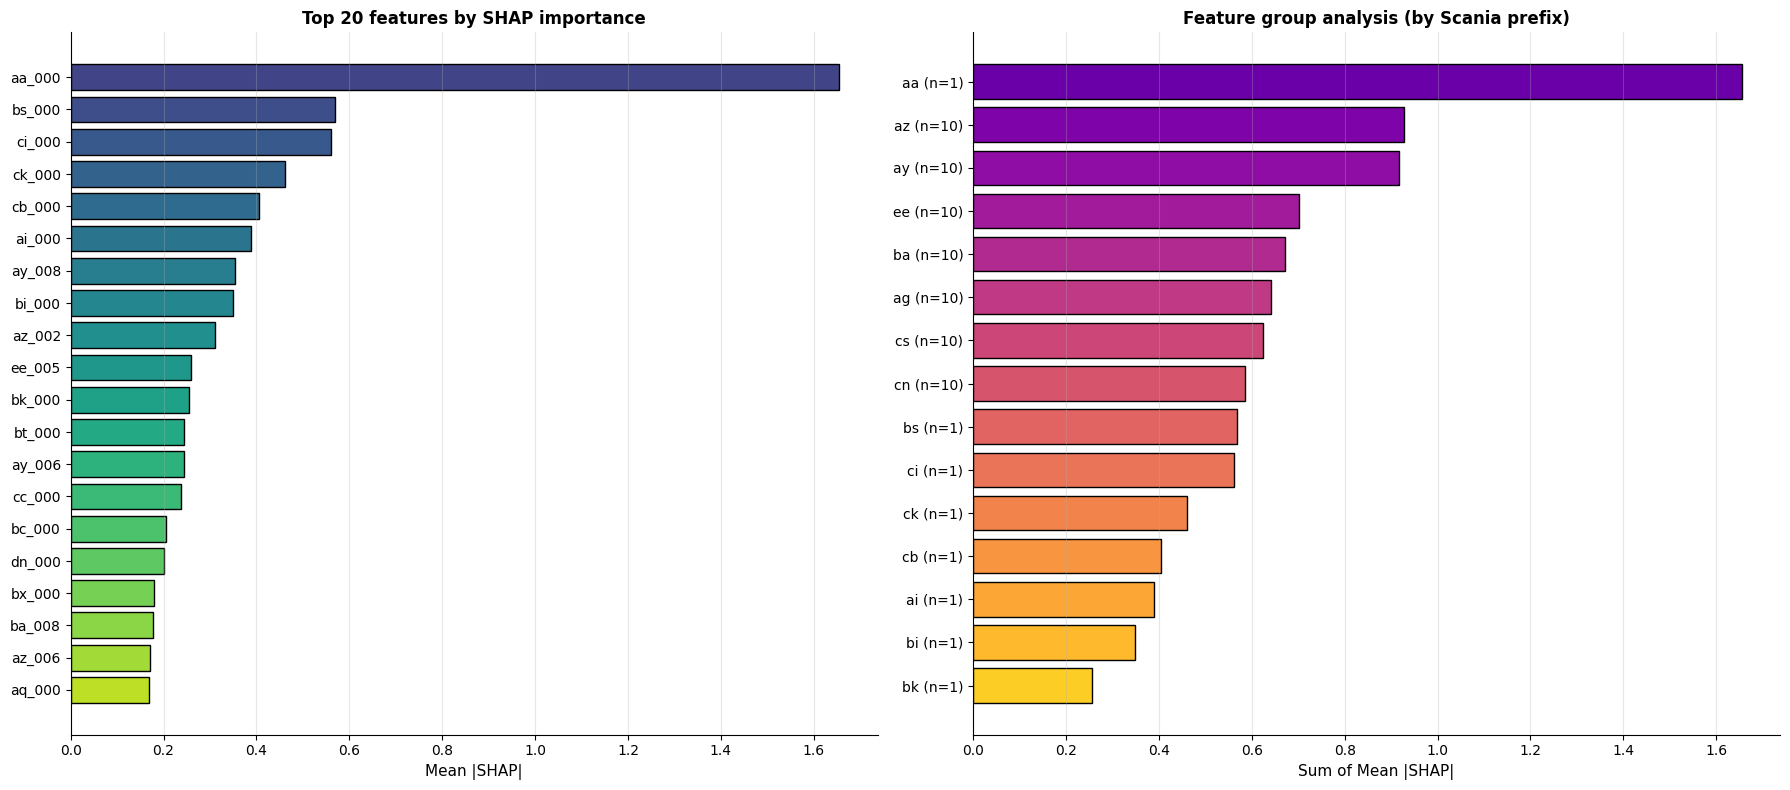


Top SHAP feature groups:
  aa:   1 features, total |SHAP| = 1.6545
  az:  10 features, total |SHAP| = 0.9268
  ay:  10 features, total |SHAP| = 0.9175
  ee:  10 features, total |SHAP| = 0.7011
  ba:  10 features, total |SHAP| = 0.6719


In [10]:
import shap

np.random.seed(SEED)
shap_idx = np.random.choice(len(X_test), 2000, replace=False)
X_shap = X_test[shap_idx]

t0 = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
print(f"SHAP computed in {time.time()-t0:.1f} sec")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:20]

print(f"\nTop 20 features by SHAP importance:")
print(f"{'Rank':<6} {'Feature':<15} {'Mean |SHAP|':>12}")
print("-" * 40)

top_features = []
for rank, i in enumerate(top_idx, 1):
    feat = feature_names[i]
    score = float(mean_abs_shap[i])
    print(f"  {rank:<4} {feat:<13} {score:>12.4f}")
    top_features.append({'feature': feat, 'mean_abs_shap': score})

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
top_n = 20
feat_names_top = [feature_names[i] for i in top_idx[:top_n]]
scores = mean_abs_shap[top_idx[:top_n]]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))
ax.barh(range(top_n), scores[::-1], color=colors[::-1], edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(feat_names_top[::-1], fontsize=10)
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Top 20 features by SHAP importance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

from collections import defaultdict
group_shap = defaultdict(float)
group_count = defaultdict(int)

for i, fname in enumerate(feature_names):
    prefix = fname.split('_')[0] if '_' in fname else fname[:2]
    group_shap[prefix] += float(mean_abs_shap[i])
    group_count[prefix] += 1

sorted_groups = sorted(group_shap.items(), key=lambda x: x[1], reverse=True)[:15]
group_labels = [f"{g} (n={group_count[g]})" for g, _ in sorted_groups]
group_values = [v for _, v in sorted_groups]
group_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(sorted_groups)))

ax = axes[1]
ax.barh(range(len(sorted_groups)), group_values[::-1], color=group_colors[::-1],
        edgecolor='black')
ax.set_yticks(range(len(sorted_groups)))
ax.set_yticklabels(group_labels[::-1], fontsize=10)
ax.set_xlabel('Sum of Mean |SHAP|')
ax.set_title('Feature group analysis (by Scania prefix)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'aps_04_shap.png', bbox_inches='tight', dpi=120)
plt.show()

shap_group_analysis = [
    {'prefix': g, 'n_features': group_count[g], 'total_abs_shap': float(v)}
    for g, v in sorted_groups
]

print(f"\nTop SHAP feature groups:")
for g, v in sorted_groups[:5]:
    print(f"  {g}: {group_count[g]:>3} features, total |SHAP| = {v:.4f}")

## Block 10  — ONNX export + verification

In [11]:
from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
import onnxruntime as ort

update_registered_converter(
    xgb.XGBClassifier, 'XGBoostXGBClassifier',
    calculate_linear_classifier_output_shapes, convert_xgboost,
    options={'nocl': [True, False], 'zipmap': [True, False, 'columns']},
)

initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]

t0 = time.time()
onnx_model = convert_sklearn(
    model,
    initial_types=initial_type,
    options={id(model): {'zipmap': False}},
    target_opset={'': 15, 'ai.onnx.ml': 3},
)
onnx_path = MODELS_DIR / 'onnx' / 'scania_aps_xgb.onnx'
with open(onnx_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f"ONNX saved in {time.time()-t0:.1f} sec: {onnx_path.name}  ({onnx_path.stat().st_size / 1024:.1f} KB)")

session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
input_name = session.get_inputs()[0].name

onnx_outputs = session.run(None, {input_name: X_test.astype(np.float32)})

onnx_proba = None
for out in onnx_outputs:
    if out.ndim == 2 and out.shape[1] == 2:
        onnx_proba = out[:, 1]
        break

if onnx_proba is not None:
    max_diff  = float(np.abs(proba_test - onnx_proba).max())
    mean_diff = float(np.abs(proba_test - onnx_proba).mean())
    
    onnx_pred = (onnx_proba >= optimal_threshold).astype(int)
    onnx_fp = int(((y_test == 0) & (onnx_pred == 1)).sum())
    onnx_fn = int(((y_test == 1) & (onnx_pred == 0)).sum())
    onnx_total_cost = COST_FP * onnx_fp + COST_FN * onnx_fn
    
    print(f"\nVerification sklearn vs ONNX:")
    print(f"  Max proba diff:  {max_diff:.6e}")
    print(f"  Mean proba diff: {mean_diff:.6e}")
    print(f"  ONNX Total Cost: {onnx_total_cost:,}")
    print(f"  Match: {'✓' if onnx_total_cost == total_cost else '✗'}")

ONNX saved in 0.2 sec: scania_aps_xgb.onnx  (521.4 KB)

Verification sklearn vs ONNX:
  Max proba diff:  4.172325e-07
  Mean proba diff: 3.247746e-08
  ONNX Total Cost: 8,910
  Match: ✓


## Block 11  — Save artifacts

In [14]:
import joblib

model_path = MODELS_DIR / 'pkl' / 'scania_aps_xgb.pkl'
joblib.dump(model, model_path)
print(f"pkl: {model_path.name}  ({model_path.stat().st_size / 1024:.1f} KB)")

sweep_results = [
    {'threshold': float(thresholds[i]),
     'fp': int(fps[i]),
     'fn': int(fns[i]),
     'cost': int(costs[i])}
    for i in range(0, len(thresholds), 10)
]

artifacts = {
    'subsystem': 'scania_aps',
    'dataset': {
        'name': 'Scania APS Failure (IDA 2016)',
        'source': 'UCI ML Repository (DOI 10.24432/C51S51)',
        'train_vehicles': int(len(train)),
        'test_vehicles':  int(len(test)),
        'features':       int(X_train.shape[1]),
        'train_positives': int(y_train.sum()),
        'test_positives':  int(y_test.sum()),
    },
    'cost_function': {
        'cost_fn': COST_FN,
        'cost_fp': COST_FP,
        'ratio': COST_FN // COST_FP,
    },
    'model': {
        'type': 'XGBClassifier',
        'params': {k: (v if not isinstance(v, np.integer) else int(v)) for k, v in xgb_params.items()},
        'training_time_sec': float(train_time),
        'roc_auc': float(auc),
    },
    'results': {
        'optimal_threshold': float(optimal_threshold),
        'total_cost': int(total_cost),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives':  int(tp),
        'true_negatives':  int(tn),
        'precision': float(precision),
        'recall':    float(recall),
        'f1_score':  float(f1),
        'default_threshold_cost': int(default_cost),
    },
    'baselines_comparison': baselines_data,
    'threshold_sweep': sweep_results,
    'shap_top_features': top_features,
    'shap_group_analysis': shap_group_analysis,
    'onnx_verification': {
        'max_proba_diff':  float(max_diff),
        'mean_proba_diff': float(mean_diff),
        'total_cost_match': bool(onnx_total_cost == total_cost),
    },
}

artifacts_path = OUTPUTS_DIR / 'data' / 'scania_aps_results.json'
with open(artifacts_path, 'w') as f:
    json.dump(artifacts, f, indent=2)

print(f"JSON: {artifacts_path.name}  ({artifacts_path.stat().st_size / 1024:.1f} KB)")

for p in [MODELS_DIR / 'pkl' / 'scania_aps_xgb.pkl',
          MODELS_DIR / 'onnx' / 'scania_aps_xgb.onnx',
          OUTPUTS_DIR / 'data' / 'scania_aps_results.json']:
    if p.exists():
        print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")
for p in sorted((OUTPUTS_DIR / 'plots').glob('aps_*.png')):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

pkl: scania_aps_xgb.pkl  (881.4 KB)
JSON: scania_aps_results.json  (9.2 KB)
  scania_aps_xgb.pkl  (881.4 KB)
  scania_aps_xgb.onnx  (521.4 KB)
  scania_aps_results.json  (9.2 KB)
  aps_01_eda.png  (34.1 KB)
  aps_02_threshold_sweep.png  (126.6 KB)
  aps_03_confusion_matrix.png  (22.7 KB)
  aps_04_shap.png  (81.8 KB)
  aps_05_baseline_comparison.png  (156.8 KB)


## Block 12  — Latency benchmark

Latency benchmark — XGBoost vs ONNX inference

Batch      XGB (μs)        ONNX (μs)       Speedup   
--------------------------------------------------
  1        457.70         24.70          18.53   x
  100      11.62          7.50           1.55    x
  1,000    2.52           3.20           0.79    x
  10,000   1.67           3.06           0.54    x
  16,000   1.14           3.42           0.33    x


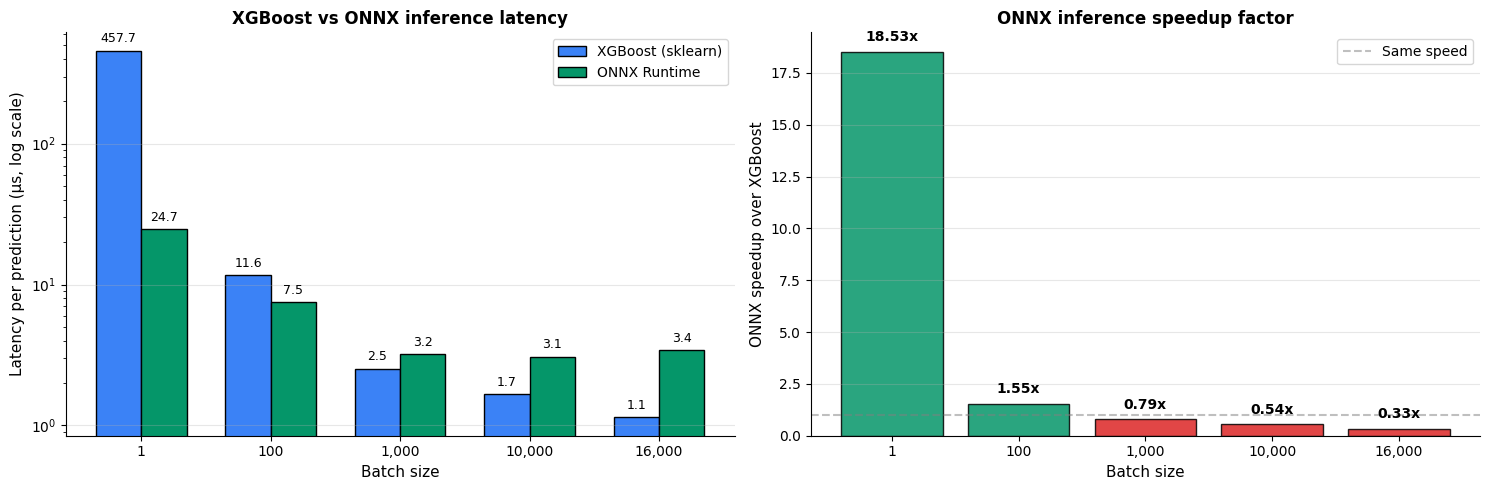


Fleet-scale inference estimate:
  Per-prediction ONNX latency: 3.1 µs
  Full fleet (76,000 vehicles): 232.8 ms


In [15]:
print(f"Latency benchmark — XGBoost vs ONNX inference")

n_runs = 100
batch_sizes = [1, 100, 1000, 10000, len(X_test)]

print(f"\n{'Batch':<10} {'XGB (μs)':<15} {'ONNX (μs)':<15} {'Speedup':<10}")
print("-" * 50)

latency_results = {}

for batch_size in batch_sizes:
    batch = X_test[:batch_size].astype(np.float32)
    
    times_xgb = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = model.predict_proba(batch)
        times_xgb.append(time.perf_counter() - t0)
    xgb_time_us = np.median(times_xgb) * 1e6 / batch_size
    
    times_onnx = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = session.run(None, {input_name: batch})
        times_onnx.append(time.perf_counter() - t0)
    onnx_time_us = np.median(times_onnx) * 1e6 / batch_size
    
    speedup = xgb_time_us / onnx_time_us
    
    print(f"  {batch_size:<8,} {xgb_time_us:<14.2f} {onnx_time_us:<14.2f} {speedup:<8.2f}x")
    
    latency_results[f'batch_{batch_size}'] = {
        'batch_size': batch_size,
        'xgb_us_per_pred':  float(xgb_time_us),
        'onnx_us_per_pred': float(onnx_time_us),
        'speedup': float(speedup),
    }

latency_path = OUTPUTS_DIR / 'data' / 'scania_aps_latency.json'
with open(latency_path, 'w') as f:
    json.dump(latency_results, f, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

batch_labels = [f'{bs:,}' for bs in batch_sizes]
xgb_times = [latency_results[f'batch_{bs}']['xgb_us_per_pred'] for bs in batch_sizes]
onnx_times = [latency_results[f'batch_{bs}']['onnx_us_per_pred'] for bs in batch_sizes]

ax = axes[0]
x = np.arange(len(batch_sizes))
width = 0.35
bars1 = ax.bar(x - width/2, xgb_times, width, label='XGBoost (sklearn)',
               color='#3b82f6', edgecolor='black')
bars2 = ax.bar(x + width/2, onnx_times, width, label='ONNX Runtime',
               color='#059669', edgecolor='black')

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(batch_labels)
ax.set_xlabel('Batch size')
ax.set_ylabel('Latency per prediction (µs, log scale)')
ax.set_title('XGBoost vs ONNX inference latency', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars1, xgb_times):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.15,
            f'{val:.1f}', ha='center', fontsize=9)
for bar, val in zip(bars2, onnx_times):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.15,
            f'{val:.1f}', ha='center', fontsize=9)

ax = axes[1]
speedups = [latency_results[f'batch_{bs}']['speedup'] for bs in batch_sizes]
colors_sp = ['#059669' if s > 1 else '#dc2626' for s in speedups]
bars = ax.bar(x, speedups, color=colors_sp, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}x', ha='center', fontsize=10, fontweight='bold')

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Same speed')
ax.set_xticks(x)
ax.set_xticklabels(batch_labels)
ax.set_xlabel('Batch size')
ax.set_ylabel('ONNX speedup over XGBoost')
ax.set_title('ONNX inference speedup factor', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'aps_06_latency_benchmark.png', bbox_inches='tight', dpi=120)
plt.show()

full_fleet_size = 76000
single_us = latency_results['batch_10000']['onnx_us_per_pred']
fleet_ms = single_us * full_fleet_size / 1000
print(f"\nFleet-scale inference estimate:")
print(f"  Per-prediction ONNX latency: {single_us:.1f} µs")
print(f"  Full fleet ({full_fleet_size:,} vehicles): {fleet_ms:.1f} ms")

In [ ]:
import shutil
import json
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ASSETS = ROOT / 'dashboard' / 'assets'
(ASSETS / 'data').mkdir(parents=True, exist_ok=True)
(ASSETS / 'plots').mkdir(parents=True, exist_ok=True)
(ASSETS / 'models').mkdir(parents=True, exist_ok=True)

print("Copying JSON artifacts...")
for f in (ROOT / 'outputs' / 'data').glob('*.json'):
    shutil.copy2(f, ASSETS / 'data' / f.name)
    print(f"  ✓ {f.name}")

print("\nCopying plots...")
plot_count = 0
for f in sorted((ROOT / 'outputs' / 'plots').glob('*.png')):
    shutil.copy2(f, ASSETS / 'plots' / f.name)
    plot_count += 1
print(f"  ✓ {plot_count} plots copied")

print("\nCopying ONNX models...")
onnx_files = ['scania_aps_xgb.onnx', 'obd_stress_xgb.onnx']
for fname in onnx_files:
    src = ROOT / 'models' / 'onnx' / fname
    if src.exists():
        shutil.copy2(src, ASSETS / 'models' / fname)
        print(f"  ✓ {fname}  ({src.stat().st_size / 1024:.1f} KB)")
    else:
        print(f"  ✗ {fname}  NOT FOUND")

for n in ['aitulogo.png']:
    src = ROOT / 'dashboard' / n
    if src.exists():
        shutil.copy2(src, ASSETS / 'aitulogo.png')
        print(f"\n  ✓ aitulogo.png copied from {n}")
        break


print("\nGenerating Scania APS scenarios...")

import joblib
df_aps = pd.read_csv(ROOT / 'data' / 'scania' / 'aps_failure_test_set.csv', na_values='na')
model_aps = joblib.load(ROOT / 'models' / 'pkl' / 'scania_aps_xgb.pkl')

feature_cols_aps = [c for c in df_aps.columns if c != 'class']
X_aps = np.nan_to_num(df_aps[feature_cols_aps].values.astype(np.float32), nan=0.0)
y_aps = (df_aps['class'] == 'pos').astype(int).values
proba_aps = model_aps.predict_proba(X_aps)[:, 1]

OPTIMAL_THRESHOLD = 0.005994842503189409

healthy_candidates = np.where((y_aps == 0) & (proba_aps < 0.0005))[0]
healthy_idx = int(healthy_candidates[np.argmin(proba_aps[healthy_candidates])])

failing_candidates = np.where((y_aps == 1) & (proba_aps > 0.95))[0]
failing_idx = int(failing_candidates[np.argmax(proba_aps[failing_candidates])])

borderline_mask = (proba_aps > 0.003) & (proba_aps < 0.015)
borderline_candidates = np.where(borderline_mask)[0]
borderline_pos = borderline_candidates[y_aps[borderline_candidates] == 1]
borderline_idx = int(borderline_pos[0]) if len(borderline_pos) > 0 else int(borderline_candidates[len(borderline_candidates) // 2])

aps_scenarios = []
for name, idx in [('healthy', healthy_idx), ('borderline', borderline_idx), ('failing', failing_idx)]:
    features = np.nan_to_num(df_aps.iloc[idx][feature_cols_aps].values.astype(np.float32), nan=0.0)
    aps_scenarios.append({
        'scenario': name,
        'truck_id': int(idx),
        'ground_truth': int(y_aps[idx]),
        'expected_proba': float(proba_aps[idx]),
        'features': features.tolist(),
    })
    print(f"  {name:>11}: truck #{idx}, proba={proba_aps[idx]:.6f}, label={'failure' if y_aps[idx] else 'healthy'}")

aps_out = {
    'optimal_threshold': float(OPTIMAL_THRESHOLD),
    'n_features': len(feature_cols_aps),
    'scenarios': aps_scenarios,
}
with open(ASSETS / 'data' / 'scania_aps_scenarios.json', 'w') as f:
    json.dump(aps_out, f)
print(f"  ✓ scania_aps_scenarios.json")

print("\nReading OBD-II stress scenarios (from notebook Block 8)...")
obd_results_path = ROOT / 'outputs' / 'data' / 'obd_stress_results.json'
with open(obd_results_path, 'r') as f:
    obd_data = json.load(f)

obd_scenarios = {
    'feature_cols': obd_data['dataset']['feature_cols'],
    'classes': obd_data['classes'],
    'slider_ranges': obd_data['slider_ranges'],
    'scenarios': obd_data['scenarios'],
}
with open(ASSETS / 'data' / 'obd_stress_scenarios.json', 'w') as f:
    json.dump(obd_scenarios, f)
print(f"  ✓ obd_stress_scenarios.json")
print(f"    {len(obd_scenarios['scenarios'])} scenarios · {len(obd_scenarios['feature_cols'])} features")

print(f"\n{'='*60}")
print(f"Dashboard assets summary:")
print(f"{'='*60}")
for sub in ['data', 'plots', 'models']:
    files = sorted((ASSETS / sub).iterdir())
    print(f"\n  {sub}/  ({len(files)} files)")
    for f in files:
        size_kb = f.stat().st_size / 1024
        print(f"    {f.name}  ({size_kb:.1f} KB)")

Copying JSON artifacts...
  ✓ can_intrusion_results.json
  ✓ obd_stress_results.json
  ✓ scania_aps_latency.json
  ✓ scania_aps_results.json
  ✓ ved_anomaly_results.json

Copying plots...
  ✓ 17 plots copied

Copying ONNX models...
  ✓ scania_aps_xgb.onnx  (521.4 KB)
  ✓ obd_stress_xgb.onnx  (508.9 KB)

  ✓ aitulogo.png copied from aitulogo.png

Generating Scania APS scenarios...
      healthy: truck #5862, proba=0.000001, label=healthy
   borderline: truck #428, proba=0.010688, label=failure
      failing: truck #11828, proba=0.999602, label=failure
  ✓ scania_aps_scenarios.json

Reading OBD-II stress scenarios (from notebook Block 8)...
  ✓ obd_stress_scenarios.json
    3 scenarios · 6 features

Dashboard assets summary:

  data/  (7 files)
    can_intrusion_results.json  (4.9 KB)
    obd_stress_results.json  (7.5 KB)
    obd_stress_scenarios.json  (2.0 KB)
    scania_aps_latency.json  (0.8 KB)
    scania_aps_results.json  (9.2 KB)
    scania_aps_scenarios.json  (4.5 KB)
    ved_anom